# Практическое задание 2: Предобработка данных и выделение признаков


In [62]:
import pandas as pd
df = pd.read_csv('all_regions.csv')

In [63]:
df.columns

Index(['brand', 'name', 'bodyType', 'color', 'fuelType', 'year', 'mileage',
       'transmission', 'power', 'price', 'vehicleConfiguration', 'engineName',
       'engineDisplacement', 'date', 'location', 'link', 'description',
       'parse_date'],
      dtype='object')

Описание признаков:

1. **brand** — бренд автомобиля (например, Toyota, BMW, Лада).

2. **name** — модель автомобиля (например, Camry, X5, Vesta).

3. **bodyType** — тип кузова автомобиля (Хэтчбек 5 дв., Лифтбек, Джип 3 дв.,Седан)
    

4. **color** — цвет автомобиля:
    * Белый
    * Черный
    * Красный 
    * Серебристый
    * и другие варианты.

5. **fuelType** — тип топлива:
    * Бензин
    * Дизель
    * Электро

6. **year** — год выпуска автомобиля.

7. **mileage** — пробег автомобиля в километрах.

8. **transmission** — тип коробки передач:
    * Механика
    * АКПП
    * Вариатор
    * Автомат
    * Робот

9. **power** — мощность двигателя в лошадиных силах.

10. **price** — цена автомобиля (в рублях или другой валюте).

11. **vehicleConfiguration** — конфигурация автомобиля (комплектация, дополнительные опции).

12. **engineName** — название двигателя.

13. **engineDisplacement** — объем двигателя в литрах.

14. **date** — дата размещения объявления на сайте.

15. **location** — местоположение продавца (город, регион).

16. **link** — ссылка на объявление на сайте.

17. **description** — описание автомобиля, предоставленное продавцом.

18. **parse_date** — дата и время сбора данных (когда информация была загружена с сайта).

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294757 entries, 0 to 1294756
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1294757 non-null  object 
 1   name                  1294757 non-null  object 
 2   bodyType              1294757 non-null  object 
 3   color                 1257029 non-null  object 
 4   fuelType              1289815 non-null  object 
 5   year                  724644 non-null   float64
 6   mileage               771799 non-null   float64
 7   transmission          1289563 non-null  object 
 8   power                 1273353 non-null  float64
 9   price                 1294757 non-null  int64  
 10  vehicleConfiguration  724647 non-null   object 
 11  engineName            720976 non-null   object 
 12  engineDisplacement    717625 non-null   object 
 13  date                  1294757 non-null  object 
 14  location              1294757 non-

In [65]:
df.describe()

,year,mileage,power,price
count,724644.000000,771799.000000,1.273353e+06,1.294757e+06
mean,2009.684535,154893.397115,1.415560e+02,1.444358e+06
std,9.367108,100738.336936,6.563943e+01,1.970257e+06
min,1936.000000,1000.000000,1.000000e+00,2.700000e+02
25%,2003.000000,82000.000000,9.800000e+01,4.250000e+05
50%,2011.000000,144000.000000,1.280000e+02,8.700000e+05
75%,2017.000000,211000.000000,1.630000e+02,1.765000e+06
max,2023.000000,1000000.000000,1.000000e+03,1.500000e+08


In [66]:
df.head()

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
0,Volkswagen,Golf,Хэтчбек 5 дв.,Серебристый,Бензин,NaN,240000.0,Механика,101.0,280000,NaN,NaN,NaN,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/volkswagen/golf/5001300...,101 л.с. люк не течёт. Документы в порядке. Со...,2023-05-02 01:00:00
1,Лада,1111 Ока,Хэтчбек 3 дв.,Фиолетовый,Бензин,1996.0,37000.0,Механика,33.0,95000,0.6 MT 11113,ВАЗ-11113,0.7 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/oka/50378140.html,"Ваз Ока Год: 2003 Цвет: Баклажан, в ПТС так и ...",2023-05-02 20:00:00
2,Toyota,Funcargo,Хэтчбек 5 дв.,Серебристый,Бензин,2002.0,295000.0,АКПП,87.0,380000,1.3 J,2NZ-FE,1.3 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/toyota/funcargo/5037751...,ХОРОШЕЕ СОСТОЯНИЕ. замена комплекта грм и помп...,2023-05-02 20:00:00
3,Лада,Гранта,Лифтбек,Серый,Бензин,2018.0,16000.0,Механика,106.0,795000,1.6 MT Comfort,ВАЗ-21127,1.6 LTR,2023-04-02 00:00:00,Майкоп,https://maykop.drom.ru/lada/granta/50382492.html,"Автомобиль в отличном техническом состоянии, н...",2023-05-02 23:00:00
4,Лада,Нива Легенд,Джип 3 дв.,Зеленый,Бензин,NaN,NaN,Механика,83.0,1022900,NaN,NaN,NaN,2023-04-02 00:00:00,Яблоновский,https://yablonovskiy.drom.ru/lada/niva_legend/...,Модель: Нива Легенд Комплектация: LADA (ВАЗ) N...,2023-05-02 20:00:00


In [67]:
df.shape

(1294757, 18)

In [68]:
df.sample(7)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,vehicleConfiguration,engineName,engineDisplacement,date,location,link,description,parse_date
362549,Toyota,Vitz,Хэтчбек 5 дв.,Серый,Бензин,2005.0,NaN,Вариатор,71.0,440000,1.0 B,1KR-FE,1.0 LTR,2023-06-10 00:00:00,Уссурийск,https://ussuriisk.drom.ru/toyota/vitz/50459301...,"Продаю TOYOTA VITZ 2005 г., привоз октябрь 201...",2023-06-10 19:00:00
155225,Subaru,Justy,Хэтчбек 5 дв.,Белый,Бензин,2018.0,73000.0,Вариатор,69.0,819000,1.0 G Smart Assist,1KR-FE,1.0 LTR,2023-05-06 00:00:00,Барнаул,https://barnaul.drom.ru/subaru/justy/48114285....,"Аукционный авто, БЕЗ ПРОБЕГА ПО РОССИИ, ЭПТС, ...",2023-05-07 02:00:00
795090,Mazda,Mazda3,Седан,Синий,Бензин,2003.0,NaN,АКПП,105.0,445000,1.6 AT Touring,Z6,1.6 LTR,2023-06-08 00:00:00,Новосибирск,https://novosibirsk.drom.ru/mazda/mazda3/51246...,Продам авто в хорошем техническом состоянии. Д...,2023-06-08 11:00:00
288191,Toyota,Passo,Хэтчбек 5 дв.,Белый,Бензин,NaN,NaN,Вариатор,69.0,585000,NaN,NaN,NaN,2023-06-12 00:00:00,Красноярск,https://krasnoyarsk.drom.ru/toyota/passo/51299...,"25 птс , один хозяин в рф. пробег реальный, то...",2023-06-12 14:00:00
791874,Toyota,Passo,Хэтчбек 5 дв.,Серый,Бензин,NaN,NaN,Вариатор,69.0,655000,NaN,NaN,NaN,2023-06-07 00:00:00,Новосибирск,https://novosibirsk.drom.ru/toyota/passo/50444...,Модель: Passo Комплектация: Toyota Passo II (C...,2023-06-08 03:00:00
677326,Honda,CR-V,Джип 5 дв.,Черный,Бензин,NaN,NaN,АКПП,160.0,750000,NaN,NaN,NaN,2023-06-17 00:00:00,Междуреченск,https://mezhdurechensk.drom.ru/honda/cr-v/5136...,капиталка двигателя на 200000,2023-06-18 08:00:00
622542,Subaru,Legacy B4,Седан,Синий,Бензин,1999.0,235000.0,АКПП,155.0,365000,2.0 B4 RS,EJ204,2.0 LTR,2023-05-16 00:00:00,Петропавловск-Камчатский,https://petropavlovsk-kamchatskiy.drom.ru/suba...,"Продам живой субарик на механике,мкпп в отличн...",2023-05-16 23:00:00


In [69]:
df.duplicated().sum()

0

In [70]:
df.isnull().sum()

brand                        0
name                         0
bodyType                     0
color                    37728
fuelType                  4942
year                    570113
mileage                 522958
transmission              5194
power                    21404
price                        0
vehicleConfiguration    570110
engineName              573781
engineDisplacement      577132
date                         0
location                     0
link                         0
description              40352
parse_date                   0
dtype: int64

<Axes: >

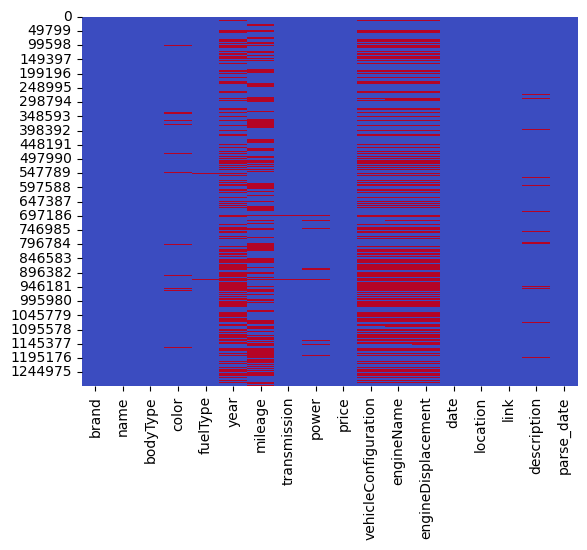

In [71]:
import seaborn as sns

sns.heatmap(df.isnull(),cbar=False, cmap='coolwarm')

In [72]:
(df.isna().sum()/len(df)) * 100

brand                    0.000000
name                     0.000000
bodyType                 0.000000
color                    2.913906
fuelType                 0.381693
year                    44.032432
mileage                 40.390436
transmission             0.401156
power                    1.653129
price                    0.000000
vehicleConfiguration    44.032201
engineName              44.315729
engineDisplacement      44.574542
date                     0.000000
location                 0.000000
link                     0.000000
description              3.116569
parse_date               0.000000
dtype: float64

In [73]:
df['engineDisplacement'] = df['engineDisplacement'].str.extract(r'([\d.]+)').astype(float) 
# [\d.] класс символов: цифра (\d) или точка (.) 
#  +  один или более таких символов подряд
# ( ) группа захвата — именно это extract возвращает

In [74]:
import numpy as np

def estimate_displacement(row):
    if pd.isna(row['engineDisplacement']) and pd.notna(row['power']):
        fuel = row['fuelType']
        hp = row['power']
        
        if fuel == 'Электро':
            return round(hp / 65, 1) 
        elif fuel == 'Дизель':
            return round(hp / 70, 1)
        else:  
            return round(hp / 60, 1)
    
    return row['engineDisplacement']  

df['engineDisplacement'] = df.apply(estimate_displacement, axis=1)

In [75]:
df[df['year'] >= 2021][['year', 'mileage']].sample(7)

,year,mileage
1079023,2021.0,NaN
576448,2023.0,NaN
1074341,2022.0,NaN
1152291,2022.0,6000.0
1086706,2022.0,NaN
1250591,2021.0,NaN
823268,2022.0,NaN


In [76]:
df = df.dropna(subset=['power'])
df = df.dropna(subset=['year'])

In [77]:
df['year'] = df['year'].astype(int)

# считаем среднее по каждому году из существующих данных
year_mean_mileage = df.groupby('year')['mileage'].mean()

# заполняем пропуски средним по году
mask = df['mileage'].isna()
df.loc[mask, 'mileage'] = df.loc[mask, 'year'].map(year_mean_mileage)


In [78]:
#df = df.dropna(subset=['mileage'])
year_mean_mileage

year
1936      1000.000000
1939    102500.000000
1943     66090.909091
1945      1000.000000
1946    100000.000000
            ...      
2019     49559.213794
2020     34724.602937
2021     18556.150794
2022      5023.121387
2023      1221.052632
Name: mileage, Length: 78, dtype: float64

In [79]:

df.shape

(720138, 18)

In [80]:
df = df.dropna(subset=['color'])
df = df.dropna(subset=['description'])
df = df.dropna(subset=['engineName'])
df = df.dropna(subset=['fuelType'])
df = df.dropna(subset=['mileage'])

In [81]:
(df.isna().sum()/len(df)) * 100

brand                   0.0
name                    0.0
bodyType                0.0
color                   0.0
fuelType                0.0
year                    0.0
mileage                 0.0
transmission            0.0
power                   0.0
price                   0.0
vehicleConfiguration    0.0
engineName              0.0
engineDisplacement      0.0
date                    0.0
location                0.0
link                    0.0
description             0.0
parse_date              0.0
dtype: float64

In [82]:
len(df['engineName'].sort_values().unique())

4136

In [83]:
df.value_counts('brand')

brand
Toyota      165217
Лада         79770
Honda        51260
Nissan       48571
Hyundai      26512
             ...  
Maxus            1
Barkas           1
SWM              1
ЗиС              1
Landwind         1
Name: count, Length: 112, dtype: int64

In [84]:

from datetime import datetime
df['date'] = pd.to_datetime(df['date'])
current_year = df['date'].max().year
df['years_in_service'] = current_year - df['year']


In [85]:
df[['power', 'price']].describe()

,power,price
count,679229.000000,6.792290e+05
mean,143.763077,1.422258e+06
std,66.481514,1.808115e+06
min,23.000000,6.000000e+03
25%,99.000000,4.200000e+05
50%,132.000000,8.800000e+05
75%,169.000000,1.800000e+06
max,800.000000,1.000000e+08


In [86]:
df[['price']].sort_values(by='price', ascending=False)

,price
869610,99999999
1189197,99999999
416347,99999999
1119652,99999999
1274558,69000000
...,...
927496,6500
672253,6001
537174,6000
711590,6000


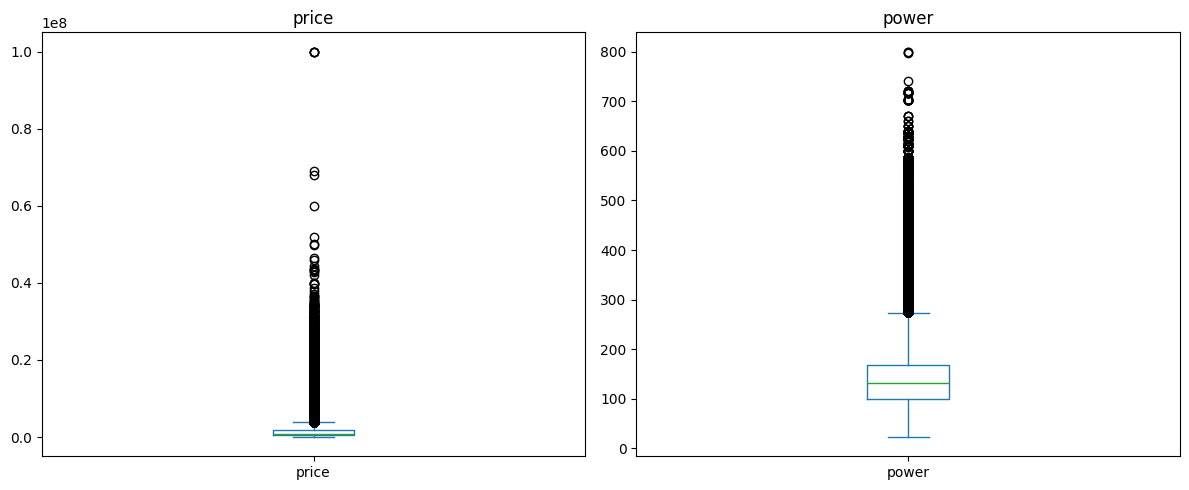

In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['price'].plot(kind='box', ax=axes[0], title='price')
df['power'].plot(kind='box', ax=axes[1], title='power')

plt.tight_layout()
plt.show()

In [88]:
df = df[(df['price'] >= 30000) & (df['price'] <= 30000000)]

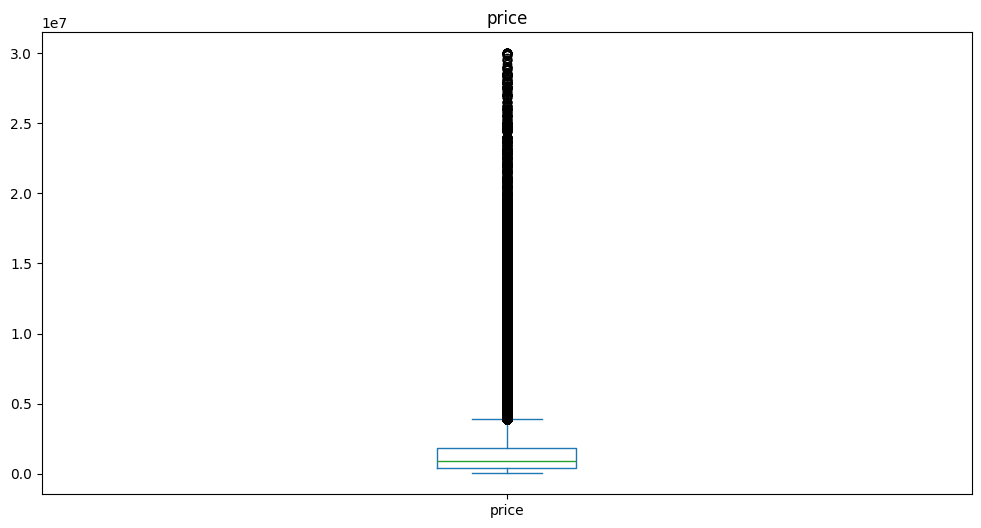

In [97]:
plt.figure(figsize=(12,6))
df['price'].plot(kind='box', title='price')
plt.show()

In [98]:
df['price'].mean()

1417548.0744141908

In [89]:
from sklearn.preprocessing import LabelEncoder

# (много уникальных значений, используем LE чтобы не раздувать датасет)
le = LabelEncoder()
for col in ['brand', 'name', 'location', 'color', 'engineName', 'vehicleConfiguration']:
    df[col] = le.fit_transform(df[col].astype(str))

# (мало уникальных значений, нет порядка между категориями)
df = pd.get_dummies(df, columns=['fuelType', 'bodyType', 'transmission'], dtype=int)

In [101]:
# 1. (интенсивность использования)
df['mileage_per_year'] = (df['mileage'] / df['years_in_service'].replace(0, 1)).round(0)

# 2. (удельная мощность двигателя)
df['power_per_liter'] = (df['power'] / df['engineDisplacement']).round(1)


In [91]:
positive_keywords = [
    # состояние
    'хорошее состояние', 'отличное состояние', 'идеальное состояние',
    'не гнилой', 'гнили нет', 'без гнили',
    # ремонт и замена
    'замена', 'новое', 'новый', 'новая', 'после капиталки', 'капремонт',
    'заменен', 'заменена', 'заменены',
    # детали
    'грм', 'помпа', 'сцепление', 'колодки', 'стойки', 'подшипники',
    'резина', 'масла поменяны',
    # двигатель
    'двигатель тянет', 'не воет', 'раздатка не воет',
    # документы
    'один владелец', '1 владелец', 'оригинал птс',
]

negative_keywords = [
    # состояние
    'битый', 'крашеный', 'после дтп', 'не на ходу', 'требует ремонта',
    'есть проблемы', 'небольшие проблемы',
    # кузов
    'ржавчина', 'гниль', 'коррозия', 'вмятина', 'царапина',
    # двигатель
    'троит', 'дымит', 'течет масло', 'стук', 'расход масла',
    # документы
    'без птс', 'утилизация', 'в залоге',
    # возраст
     'старый'
]


def estimate_condition(text):
    
    text = text.lower()
    score = 0  # базовая оценка
    
    for word in positive_keywords:
        if word in text:
            score += 0.3
    
    for word in negative_keywords:
        if word in text:
            score -= 0.4

    return round(score, 1)

df['condition_score'] = df['description'].apply(estimate_condition)

print(df['condition_score'].describe())

count    678634.000000
mean          0.226303
std           0.390191
min          -2.000000
25%           0.000000
50%           0.000000
75%           0.300000
max           3.900000
Name: condition_score, dtype: float64


In [92]:
df.sample(7)

,brand,name,color,year,mileage,power,price,vehicleConfiguration,engineName,engineDisplacement,...,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,mileage_per_year,power_per_liter,condition_score
1172320,25,1486,15,2021,18556.150794,249.0,5649900,11882,2054,2.0,...,0,0,0,0,0,0,1,9278.0,124.5,0.3
642532,107,1635,3,2015,138000.000000,106.0,625000,7224,4042,1.6,...,0,0,0,0,0,1,0,17250.0,66.2,0.3
1027602,107,1640,13,2011,151457.997152,82.0,400000,7912,4003,1.6,...,0,0,0,0,0,1,0,12621.0,51.2,0.3
440067,96,1444,1,1998,259210.682493,130.0,655000,13116,260,2.0,...,0,0,0,1,0,0,0,10368.0,65.0,0.9
496870,107,47,5,2004,174000.000000,89.0,118000,7645,4038,1.6,...,0,0,1,0,0,1,0,9158.0,55.6,1.2
60439,71,1032,14,2014,110000.000000,98.0,700000,130,2527,1.2,...,0,0,1,0,1,0,0,12222.0,81.7,0.3
1215160,107,1659,12,2008,200000.000000,98.0,129000,7863,4039,1.6,...,0,0,1,0,0,1,0,13333.0,61.2,0.3


In [93]:
df

,brand,name,color,year,mileage,power,price,vehicleConfiguration,engineName,engineDisplacement,...,bodyType_Универсал,bodyType_Хэтчбек 3 дв.,bodyType_Хэтчбек 5 дв.,transmission_АКПП,transmission_Вариатор,transmission_Механика,transmission_Робот,mileage_per_year,power_per_liter,condition_score
1,107,6,14,1996,37000.00000,33.0,95000,1488,4000,0.7,...,0,1,0,0,0,1,0,1370.0,47.1,0.4
2,96,642,11,2002,295000.00000,87.0,380000,2684,202,1.3,...,0,0,1,1,0,0,0,14048.0,66.9,2.1
3,107,1640,12,2018,16000.00000,106.0,795000,7224,4040,1.6,...,0,0,0,0,0,1,0,3200.0,66.2,0.0
9,15,1029,5,2002,220000.00000,80.0,450000,8648,4049,1.7,...,0,0,0,0,0,1,0,10476.0,47.1,2.1
12,107,49,15,2007,185000.00000,81.0,120000,7057,4003,1.6,...,0,0,1,0,0,1,0,11562.0,50.6,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294751,54,1203,13,2005,212614.12848,299.0,1200000,22412,286,4.4,...,0,0,0,1,0,0,0,11812.0,68.0,0.0
1294753,107,39,1,1985,300000.00000,64.0,165000,2828,4012,1.3,...,0,0,0,0,0,1,0,7895.0,49.2,0.0
1294754,96,356,12,2020,32000.00000,202.0,3100000,17512,498,2.5,...,0,0,0,1,0,0,0,10667.0,80.8,0.0
1294755,107,121,1,1995,354000.00000,79.0,298000,8612,4046,1.7,...,0,0,0,0,0,1,0,12643.0,46.5,0.9
